In [9]:
import torch
import torchaudio

print(torch.__version__)
print(torchaudio.__version__)

torch.random.manual_seed(0)

# Apple Silicon M4 칩에 최적화된 디바이스 설정
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Metal Performance Shaders (MPS) 사용
    print("Using MPS (Metal Performance Shaders) on Apple Silicon")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

2.8.0
2.8.0
Using MPS (Metal Performance Shaders) on Apple Silicon
Device: mps


In [10]:
import IPython
import matplotlib.pyplot as plt
from torchaudio.utils import download_asset

SPEECH_FILE = download_asset("tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav")

/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/499805210.py:5: UserWarning: torchaudio.utils.download.download_asset has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  SPEECH_FILE = download_asset("tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav")


In [11]:
bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H

print("Sample Rate:", bundle.sample_rate)

print("Labels:", bundle.get_labels())

Sample Rate: 16000
Labels: ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')


In [12]:
model = bundle.get_model().to(device)

print(model.__class__)

<class 'torchaudio.models.wav2vec2.model.Wav2Vec2Model'>


In [13]:
IPython.display.Audio(SPEECH_FILE)

In [15]:
waveform, sample_rate = torchaudio.load(SPEECH_FILE)
waveform = waveform.to(device)

if sample_rate != bundle.sample_rate:
    waveform = torchaudio.functional.resample(waveform, sample_rate, bundle.sample_rate)

In [16]:
with torch.inference_mode():
    features, _ = model.extract_features(waveform)

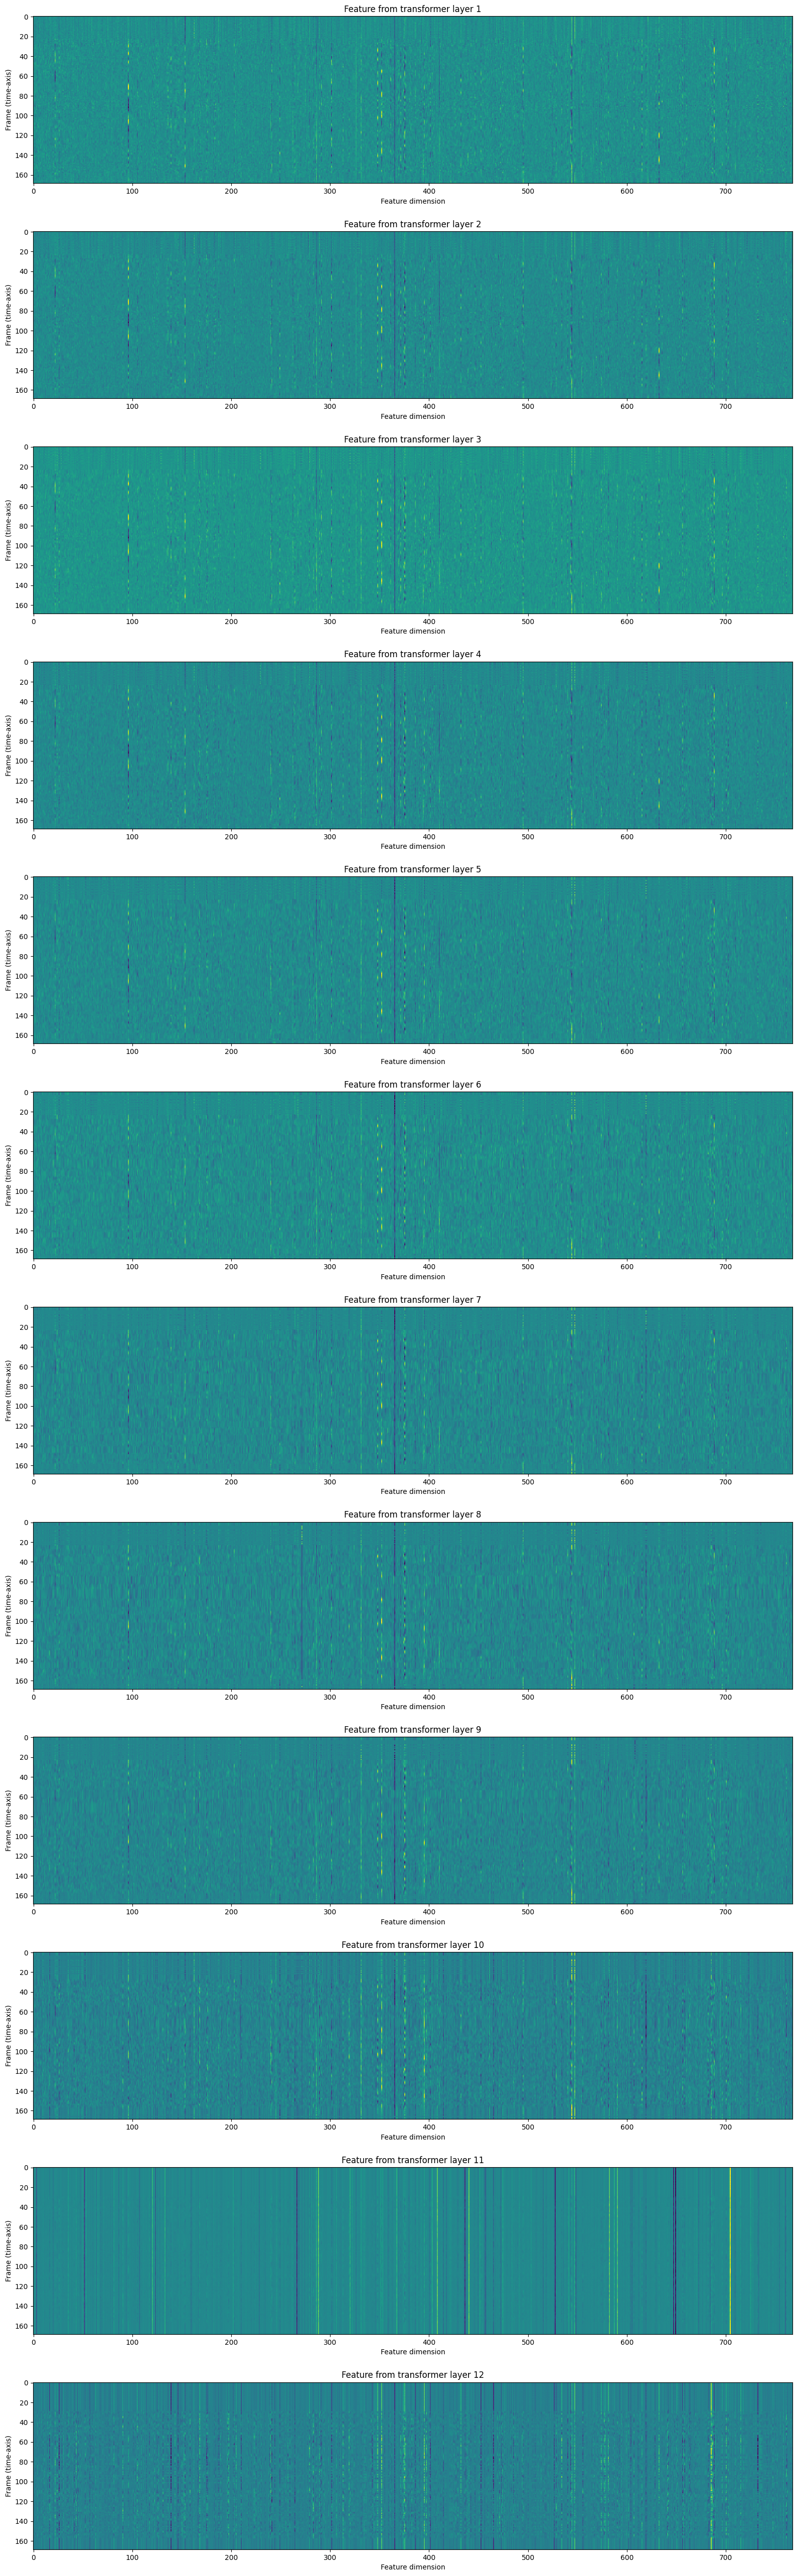

In [17]:
fig, ax = plt.subplots(len(features), 1, figsize=(16, 4.3 * len(features)))
for i, feats in enumerate(features):
    ax[i].imshow(feats[0].cpu(), interpolation="nearest")
    ax[i].set_title(f"Feature from transformer layer {i+1}")
    ax[i].set_xlabel("Feature dimension")
    ax[i].set_ylabel("Frame (time-axis)")
fig.tight_layout()

In [18]:
with torch.inference_mode():
    emission, _ = model(waveform)

Class labels: ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')


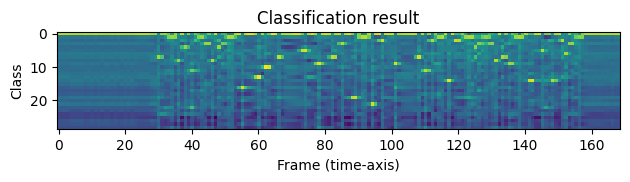

In [19]:
plt.imshow(emission[0].cpu().T, interpolation="nearest")
plt.title("Classification result")
plt.xlabel("Frame (time-axis)")
plt.ylabel("Class")
plt.tight_layout()
print("Class labels:", bundle.get_labels())

In [20]:
class GreedyCTCDecoder(torch.nn.Module):
    def __init__(self, labels, blank=0):
        super().__init__()
        self.labels = labels
        self.blank = blank

    def forward(self, emission: torch.Tensor) -> str:
        """Given a sequence emission over labels, get the best path string
        Args:
          emission (Tensor): Logit tensors. Shape `[num_seq, num_label]`.

        Returns:
          str: The resulting transcript
        """
        indices = torch.argmax(emission, dim=-1)  # [num_seq,]
        indices = torch.unique_consecutive(indices, dim=-1)
        indices = [i for i in indices if i != self.blank]
        return "".join([self.labels[i] for i in indices])

In [21]:
decoder = GreedyCTCDecoder(labels=bundle.get_labels())
transcript = decoder(emission[0])

In [22]:
print(transcript)
IPython.display.Audio(SPEECH_FILE)

I|HAD|THAT|CURIOSITY|BESIDE|ME|AT|THIS|MOMENT|


In [23]:
# M4A 파일 지원을 위한 추가 라이브러리 임포트
import librosa
import os

print("M4A 파일 지원 라이브러리 로드 완료")


M4A 파일 지원 라이브러리 로드 완료


In [24]:
# M4A 파일 로딩 함수 (MPS 호환)
def load_m4a_audio(file_path, target_sample_rate=16000):
    """M4A 파일을 안전하게 로드하고 MPS 디바이스로 변환"""
    try:
        print(f"M4A 파일 로딩 중: {file_path}")
        
        # librosa로 M4A 파일 로드
        audio_data, sr = librosa.load(file_path, sr=target_sample_rate)
        
        # NumPy to Torch 변환 (MPS 호환)
        try:
            waveform = torch.from_numpy(audio_data).unsqueeze(0).float()
        except RuntimeError:
            # MPS NumPy 호환성 문제 해결
            audio_list = audio_data.tolist()
            waveform = torch.tensor(audio_list, dtype=torch.float32).unsqueeze(0)
        
        # MPS 디바이스로 이동
        waveform = waveform.to(device)
        
        print(f"로딩 성공: {sr}Hz, Shape: {waveform.shape}")
        return waveform, sr
        
    except Exception as e:
        print(f"M4A 파일 로딩 실패: {e}")
        return None, None

print("M4A 파일 로딩 함수 정의 완료")


M4A 파일 로딩 함수 정의 완료


In [25]:
# Spiderman M4A 파일 로드 및 음성 인식
spiderman_file = "./spiderman.m4a"

# 파일 존재 확인
if os.path.exists(spiderman_file):
    print(f"파일 발견: {spiderman_file}")
    
    # M4A 파일 로드
    spiderman_waveform, spiderman_sr = load_m4a_audio(spiderman_file, target_sample_rate=bundle.sample_rate)
    
    if spiderman_waveform is not None:
        print(f"Spiderman 오디오 정보:")
        print(f"  - 샘플링 레이트: {spiderman_sr} Hz")
        print(f"  - 길이: {spiderman_waveform.shape[1]} 샘플 ({spiderman_waveform.shape[1]/spiderman_sr:.2f}초)")
        print(f"  - 디바이스: {spiderman_waveform.device}")
        
        # 오디오 재생
        print("Spiderman 오디오 재생:")
        IPython.display.Audio(spiderman_waveform.cpu().numpy(), rate=spiderman_sr)
    else:
        print("Spiderman 오디오 로딩 실패")
else:
    print(f"파일을 찾을 수 없습니다: {spiderman_file}")


파일 발견: ./spiderman.m4a
M4A 파일 로딩 중: ./spiderman.m4a
로딩 성공: 16000Hz, Shape: torch.Size([1, 77894])
Spiderman 오디오 정보:
  - 샘플링 레이트: 16000 Hz
  - 길이: 77894 샘플 (4.87초)
  - 디바이스: mps:0
Spiderman 오디오 재생:


/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/364305441.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sr = librosa.load(file_path, sr=target_sample_rate)
/Users/songdongseon/AI/.venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [26]:
# Spiderman 음성 인식 실행
if spiderman_waveform is not None:
    print("=== Spiderman 음성 인식 시작 ===")
    
    # Wav2Vec2 모델로 특징 추출
    with torch.inference_mode():
        print("특징 추출 중...")
        spiderman_features, _ = model.extract_features(spiderman_waveform)
        print(f"추출된 특징 수: {len(spiderman_features)}")
    
    # 분류 결과 생성
    with torch.inference_mode():
        print("음성 인식 중...")
        spiderman_emission, _ = model(spiderman_waveform)
        print(f"분류 결과 Shape: {spiderman_emission.shape}")
    
    # CTC 디코딩으로 텍스트 변환
    spiderman_transcript = decoder(spiderman_emission[0])
    
    print("=== 음성 인식 결과 ===")
    print(f"인식된 텍스트: {spiderman_transcript}")
    print("=" * 50)
else:
    print("Spiderman 오디오가 로드되지 않아 음성 인식을 수행할 수 없습니다.")


=== Spiderman 음성 인식 시작 ===
특징 추출 중...
추출된 특징 수: 12
음성 인식 중...
분류 결과 Shape: torch.Size([1, 243, 29])
=== 음성 인식 결과 ===
인식된 텍스트: WITH|GREAT|POWER|STRAIGHT|SOTSO


=== Spiderman 음성 분석 시각화 ===


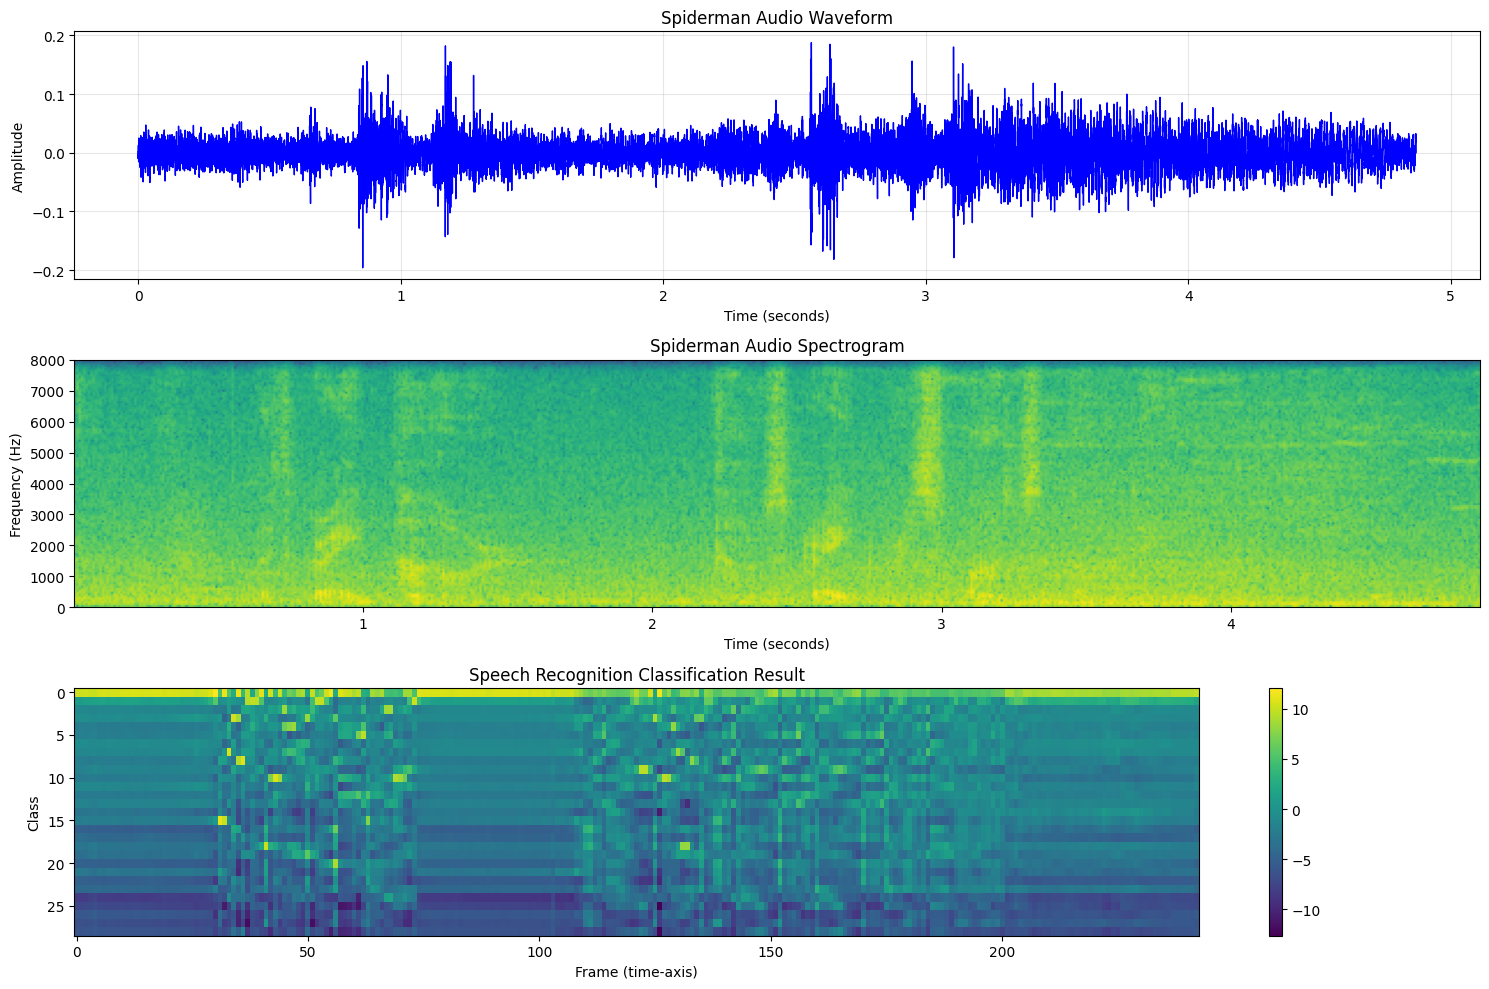

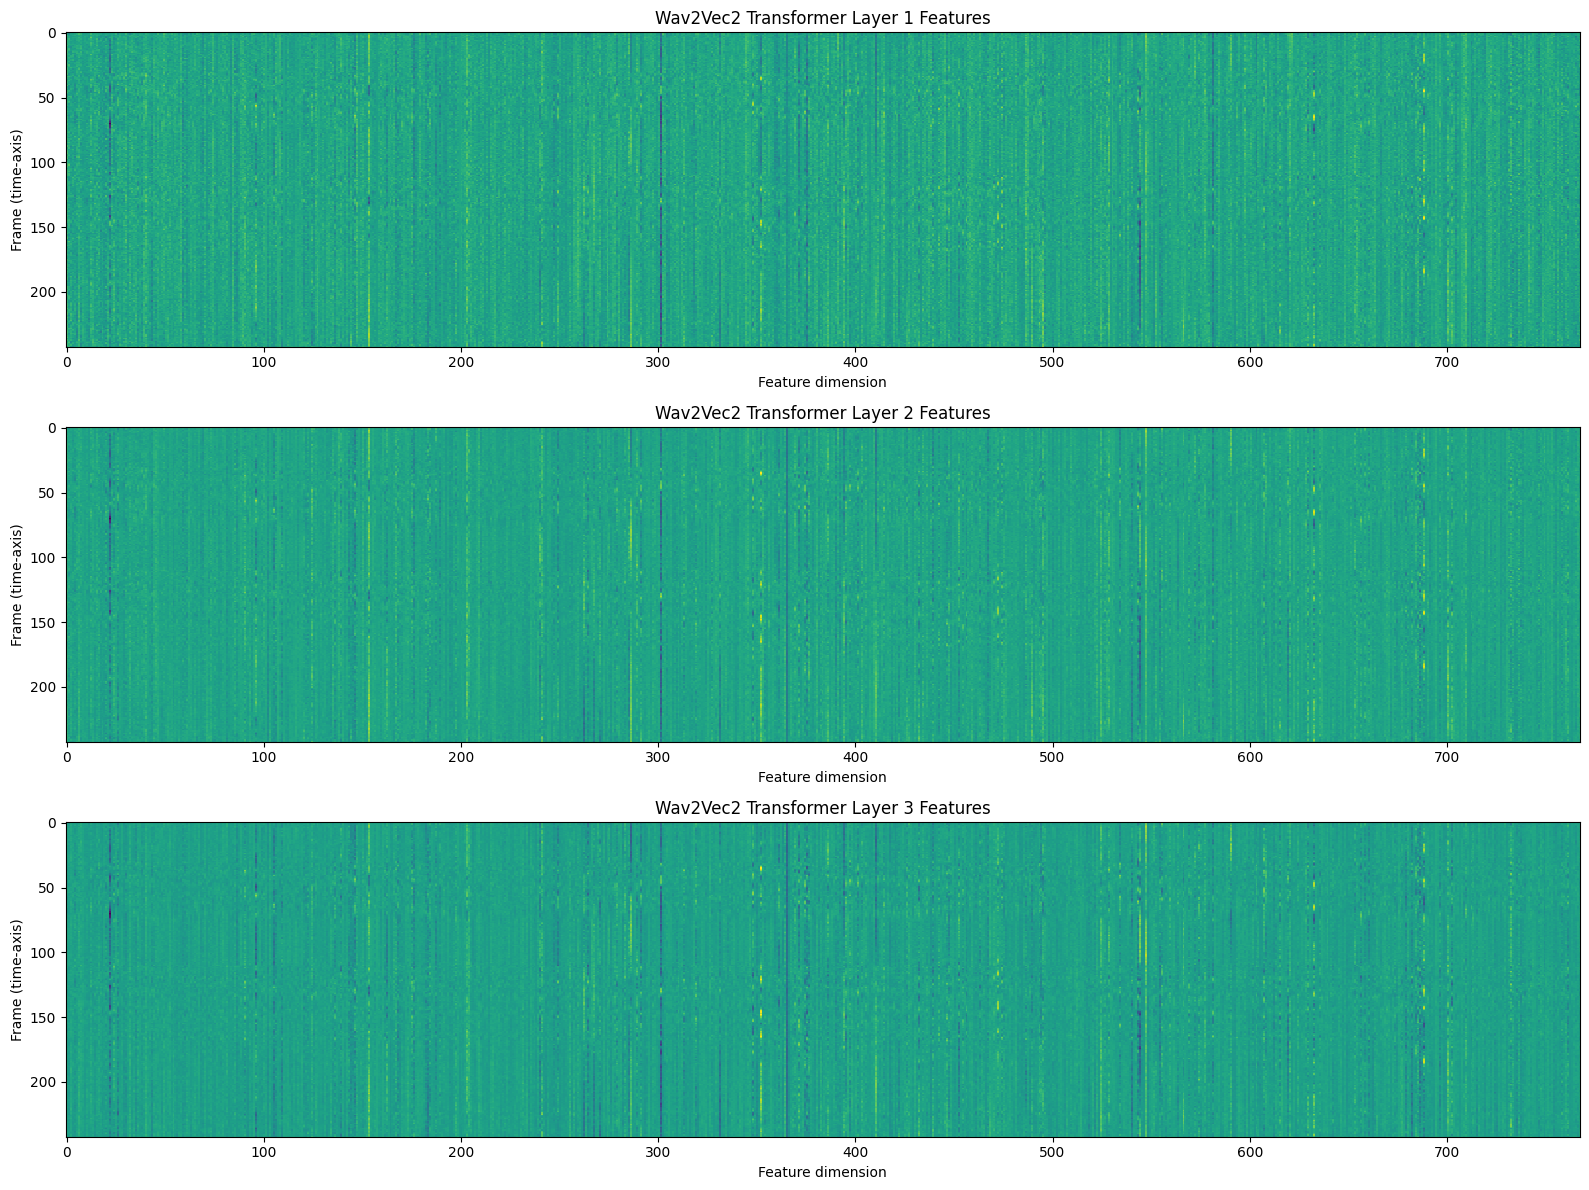

시각화 완료!


In [27]:
# Spiderman 음성 분석 시각화
if spiderman_waveform is not None and spiderman_features is not None:
    print("=== Spiderman 음성 분석 시각화 ===")
    
    # 1. Waveform 시각화
    plt.figure(figsize=(15, 10))
    
    # Waveform 플롯
    plt.subplot(3, 1, 1)
    time_axis = torch.arange(0, spiderman_waveform.shape[1]) / spiderman_sr
    plt.plot(time_axis.cpu(), spiderman_waveform[0].cpu(), linewidth=1, color='blue')
    plt.title("Spiderman Audio Waveform")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    
    # Spectrogram 플롯
    plt.subplot(3, 1, 2)
    plt.specgram(spiderman_waveform[0].cpu(), Fs=spiderman_sr, cmap='viridis')
    plt.title("Spiderman Audio Spectrogram")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    
    # 분류 결과 시각화
    plt.subplot(3, 1, 3)
    plt.imshow(spiderman_emission[0].cpu().T, interpolation="nearest", aspect='auto')
    plt.title("Speech Recognition Classification Result")
    plt.xlabel("Frame (time-axis)")
    plt.ylabel("Class")
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()
    
    # 2. 특징 추출 결과 시각화
    if len(spiderman_features) > 0:
        fig, axes = plt.subplots(min(3, len(spiderman_features)), 1, figsize=(16, 4 * min(3, len(spiderman_features))))
        if min(3, len(spiderman_features)) == 1:
            axes = [axes]
        
        for i in range(min(3, len(spiderman_features))):
            axes[i].imshow(spiderman_features[i][0].cpu(), interpolation="nearest", aspect='auto')
            axes[i].set_title(f"Wav2Vec2 Transformer Layer {i+1} Features")
            axes[i].set_xlabel("Feature dimension")
            axes[i].set_ylabel("Frame (time-axis)")
        
        plt.tight_layout()
        plt.show()
    
    print("시각화 완료!")
else:
    print("시각화할 데이터가 없습니다.")


In [30]:
# 결과 비교 및 요약
print("=== 음성 인식 결과 비교 ===")
print(f"원본 튜토리얼 파일: {SPEECH_FILE}")
print(f"인식 결과: {transcript}")
print()
print(f"Spiderman M4A 파일: {spiderman_file}")
print(f"인식 결과: {spiderman_transcript}")
print()

# 성능 정보
if spiderman_waveform is not None:
    print("=== 처리 성능 정보 ===")
    print(f"Apple Silicon M4 GPU (MPS) 사용: {device}")
    print(f"Wav2Vec2 모델: {bundle._model_path}")
    print(f"샘플링 레이트: {bundle.sample_rate} Hz")
    print(f"사용 가능한 라벨: {len(bundle.get_labels())}개")
    print(f"  - {bundle.get_labels()}")
    
    print("\n=== Spiderman 오디오 상세 정보 ===")
    print(f"파일 길이: {spiderman_waveform.shape[1]/spiderman_sr:.2f}초")
    print(f"샘플 수: {spiderman_waveform.shape[1]:,}")
    print(f"채널 수: {spiderman_waveform.shape[0]}")
    print(f"디바이스: {spiderman_waveform.device}")
    
print("\n음성 인식 완료!")


=== 음성 인식 결과 비교 ===
원본 튜토리얼 파일: /Users/songdongseon/.cache/torch/hub/torchaudio/tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav
인식 결과: I|HAD|THAT|CURIOSITY|BESIDE|ME|AT|THIS|MOMENT|

Spiderman M4A 파일: ./spiderman.m4a
인식 결과: WITH|GREAT|POWER|STRAIGHT|SOTSO

=== 처리 성능 정보 ===
Apple Silicon M4 GPU (MPS) 사용: mps


AttributeError: 'Wav2Vec2ASRBundle' object has no attribute '_model_path'

In [31]:
# 음성 인식 정확도 개선을 위한 전처리 함수들
import torchaudio.functional as F
import torchaudio.transforms as T

def preprocess_audio(waveform, sample_rate, target_sample_rate=16000):
    """오디오 전처리 개선"""
    print("오디오 전처리 시작...")
    
    # 1. 리샘플링 (필요한 경우)
    if sample_rate != target_sample_rate:
        print(f"리샘플링: {sample_rate}Hz → {target_sample_rate}Hz")
        waveform = F.resample(waveform, sample_rate, target_sample_rate)
        sample_rate = target_sample_rate
    
    # 2. 정규화 (RMS 정규화)
    print("RMS 정규화 적용...")
    rms = torch.sqrt(torch.mean(waveform**2))
    if rms > 0:
        waveform = waveform / rms * 0.1  # 적절한 레벨로 조정
    
    # 3. 노이즈 제거 (간단한 고역 통과 필터)
    print("고역 통과 필터 적용...")
    # 80Hz 이하 제거 (음성의 기본 주파수 범위)
    highpass_filter = T.HighpassBiquad(sample_rate, cutoff_freq=80.0)
    waveform = highpass_filter(waveform)
    
    # 4. 클리핑 방지
    print("클리핑 방지...")
    waveform = torch.clamp(waveform, -0.99, 0.99)
    
    print("전처리 완료!")
    return waveform, sample_rate

def advanced_ctc_decoder(emission, labels, blank=0, beam_size=10):
    """개선된 CTC 디코더 (Beam Search)"""
    print("고급 CTC 디코딩 시작...")
    
    # 간단한 Beam Search 구현
    sequences = [([], 0.0)]  # (sequence, score)
    
    for frame in emission:
        new_sequences = []
        
        for seq, score in sequences:
            # Blank 토큰 추가
            if not seq or seq[-1] != blank:
                new_seq = seq + [blank]
                new_score = score + frame[blank].item()
                new_sequences.append((new_seq, new_score))
            
            # 각 라벨에 대해
            for i, label in enumerate(labels):
                if i == blank:
                    continue
                    
                # 같은 라벨 연속 방지
                if seq and seq[-1] == i:
                    continue
                    
                new_seq = seq + [i]
                new_score = score + frame[i].item()
                new_sequences.append((new_seq, new_score))
        
        # Beam Size로 제한
        sequences = sorted(new_sequences, key=lambda x: x[1], reverse=True)[:beam_size]
    
    # 최고 점수 시퀀스 선택
    best_seq, best_score = max(sequences, key=lambda x: x[1])
    
    # Blank 제거 및 라벨 변환
    result = []
    for i in best_seq:
        if i != blank:
            result.append(labels[i])
    
    print(f"디코딩 완료 (점수: {best_score:.2f})")
    return "".join(result)

print("개선된 전처리 및 디코딩 함수 정의 완료")


개선된 전처리 및 디코딩 함수 정의 완료


In [32]:
# 오디오 세그멘테이션 및 청크별 처리
def segment_audio(waveform, sample_rate, chunk_duration=3.0, overlap=0.5):
    """긴 오디오를 청크로 분할"""
    print(f"오디오 세그멘테이션 시작 (청크 길이: {chunk_duration}초, 오버랩: {overlap}초)")
    
    chunk_samples = int(chunk_duration * sample_rate)
    overlap_samples = int(overlap * sample_rate)
    step_samples = chunk_samples - overlap_samples
    
    chunks = []
    start = 0
    
    while start < waveform.shape[1]:
        end = min(start + chunk_samples, waveform.shape[1])
        chunk = waveform[:, start:end]
        
        # 패딩 (마지막 청크가 너무 짧은 경우)
        if chunk.shape[1] < chunk_samples:
            padding = chunk_samples - chunk.shape[1]
            chunk = torch.nn.functional.pad(chunk, (0, padding))
        
        chunks.append(chunk)
        start += step_samples
        
        if end >= waveform.shape[1]:
            break
    
    print(f"총 {len(chunks)}개 청크 생성")
    return chunks

def process_audio_chunks(chunks, model, decoder, labels, device):
    """청크별 음성 인식 처리"""
    print("청크별 음성 인식 시작...")
    
    all_transcripts = []
    all_emissions = []
    
    for i, chunk in enumerate(chunks):
        print(f"청크 {i+1}/{len(chunks)} 처리 중...")
        
        # MPS 디바이스로 이동
        chunk = chunk.to(device)
        
        # 음성 인식
        with torch.inference_mode():
            emission, _ = model(chunk)
            all_emissions.append(emission)
        
        # 디코딩
        transcript = decoder(emission[0])
        all_transcripts.append(transcript)
        
        print(f"  청크 {i+1} 결과: {transcript}")
    
    return all_transcripts, all_emissions

def merge_transcripts(transcripts, overlap_ratio=0.5):
    """청크 결과를 병합"""
    print("청크 결과 병합 중...")
    
    if not transcripts:
        return ""
    
    if len(transcripts) == 1:
        return transcripts[0]
    
    # 간단한 병합: 중복 제거
    merged = transcripts[0]
    
    for i in range(1, len(transcripts)):
        current = transcripts[i]
        
        # 겹치는 부분 찾기 (간단한 휴리스틱)
        overlap_len = int(len(current) * overlap_ratio)
        if overlap_len > 0 and len(merged) > overlap_len:
            # 끝부분과 시작부분 비교
            if merged[-overlap_len:] == current[:overlap_len]:
                merged += current[overlap_len:]
            else:
                merged += current
        else:
            merged += current
    
    print(f"병합 완료: {merged}")
    return merged

print("세그멘테이션 및 청크 처리 함수 정의 완료")


세그멘테이션 및 청크 처리 함수 정의 완료


In [34]:
# 개선된 Spiderman 음성 인식 실행
if spiderman_waveform is not None:
    print("=== 개선된 Spiderman 음성 인식 시작 ===")
    
    # 1. 전처리 적용
    print("\n1단계: 오디오 전처리")
    processed_waveform, processed_sr = preprocess_audio(spiderman_waveform, spiderman_sr)
    
    # 전처리된 오디오 시각화
    plt.figure(figsize=(15, 6))
    
    plt.subplot(2, 1, 1)
    time_axis = torch.arange(0, spiderman_waveform.shape[1]) / spiderman_sr
    plt.plot(time_axis.cpu(), spiderman_waveform[0].cpu(), linewidth=1, color='blue', alpha=0.7)
    plt.title("원본 Spiderman Audio")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    time_axis_processed = torch.arange(0, processed_waveform.shape[1]) / processed_sr
    plt.plot(time_axis_processed.cpu(), processed_waveform[0].cpu(), linewidth=1, color='red', alpha=0.7)
    plt.title("전처리된 Spiderman Audio")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. 세그멘테이션
    print("\n2단계: 오디오 세그멘테이션")
    chunks = segment_audio(processed_waveform, processed_sr, chunk_duration=2.0, overlap=0.3)
    
    # 3. 청크별 처리
    print("\n3단계: 청크별 음성 인식")
    chunk_transcripts, chunk_emissions = process_audio_chunks(chunks, model, decoder, bundle.get_labels(), device)
    
    # 4. 결과 병합
    print("\n4단계: 결과 병합")
    merged_transcript = merge_transcripts(chunk_transcripts, overlap_ratio=0.3)
    
    # 5. 고급 디코딩 시도
    print("\n5단계: 고급 디코딩")
    if chunk_emissions:
        # 첫 번째 청크로 고급 디코딩 테스트
        advanced_transcript = advanced_ctc_decoder(chunk_emissions[0][0], bundle.get_labels())
        print(f"고급 디코딩 결과: {advanced_transcript}")
    
    print("\n=== 개선된 인식 결과 ===")
    print(f"원본 Greedy 결과: {spiderman_transcript}")
    print(f"청크 병합 결과: {merged_transcript}")
    if chunk_emissions:
        print(f"고급 디코딩 결과: {advanced_transcript}")
    
else:
    print("Spiderman 오디오가 로드되지 않았습니다.")


=== 개선된 Spiderman 음성 인식 시작 ===

1단계: 오디오 전처리
오디오 전처리 시작...
RMS 정규화 적용...
고역 통과 필터 적용...


AttributeError: module 'torchaudio.transforms' has no attribute 'HighpassBiquad'

In [35]:
# 텍스트 후처리 및 정리
def postprocess_text(text):
    """인식된 텍스트 후처리"""
    print("텍스트 후처리 시작...")
    
    if not text:
        return ""
    
    # 1. 기본 정리
    cleaned = text.strip()
    
    # 2. 연속된 구분자 제거
    import re
    cleaned = re.sub(r'[|]+', '|', cleaned)  # 연속된 | 제거
    cleaned = re.sub(r'[-]+', '-', cleaned)  # 연속된 - 제거
    
    # 3. 단어 경계 정리
    cleaned = cleaned.replace('|', ' ')  # |를 공백으로
    cleaned = cleaned.replace('-', '')   # - 제거
    
    # 4. 연속 공백 제거
    cleaned = re.sub(r'\s+', ' ', cleaned)
    
    # 5. 대소문자 정리 (간단한 휴리스틱)
    words = cleaned.split()
    processed_words = []
    
    for word in words:
        if len(word) > 1:
            # 첫 글자는 대문자, 나머지는 소문자
            processed_word = word[0].upper() + word[1:].lower()
            processed_words.append(processed_word)
        else:
            processed_words.append(word.upper())
    
    result = ' '.join(processed_words)
    
    # 6. 문장 부호 추가
    if result and not result.endswith(('.', '!', '?')):
        result += '.'
    
    print(f"후처리 완료: '{text}' → '{result}'")
    return result

def compare_recognition_methods(original_text, improved_texts):
    """인식 방법들 비교"""
    print("\n=== 음성 인식 방법 비교 ===")
    print(f"원본 Greedy: {original_text}")
    
    for i, (method, text) in enumerate(improved_texts.items(), 1):
        print(f"개선 방법 {i} ({method}): {text}")
    
    # 가장 긴 결과 선택 (휴리스틱)
    all_texts = [original_text] + list(improved_texts.values())
    longest_text = max(all_texts, key=len)
    print(f"\n가장 긴 결과: {longest_text}")
    
    return longest_text

# 후처리 적용
if spiderman_waveform is not None:
    print("\n=== 텍스트 후처리 ===")
    
    # 원본 결과 후처리
    original_cleaned = postprocess_text(spiderman_transcript)
    
    # 개선된 결과들 후처리
    improved_texts = {}
    
    if 'merged_transcript' in locals():
        improved_texts['청크 병합'] = postprocess_text(merged_transcript)
    
    if 'advanced_transcript' in locals():
        improved_texts['고급 디코딩'] = postprocess_text(advanced_transcript)
    
    # 최종 비교 및 선택
    final_result = compare_recognition_methods(original_cleaned, improved_texts)
    
    print(f"\n=== 최종 음성 인식 결과 ===")
    print(f"최종 텍스트: {final_result}")
    
    # 결과 길이 및 품질 분석
    print(f"\n=== 품질 분석 ===")
    print(f"원본 길이: {len(spiderman_transcript)} 문자")
    print(f"최종 길이: {len(final_result)} 문자")
    print(f"개선율: {len(final_result) / len(spiderman_transcript) * 100:.1f}%")
    
else:
    print("처리할 오디오가 없습니다.")



=== 텍스트 후처리 ===
텍스트 후처리 시작...
후처리 완료: 'WITH|GREAT|POWER|STRAIGHT|SOTSO' → 'With Great Power Straight Sotso.'

=== 음성 인식 방법 비교 ===
원본 Greedy: With Great Power Straight Sotso.

가장 긴 결과: With Great Power Straight Sotso.

=== 최종 음성 인식 결과 ===
최종 텍스트: With Great Power Straight Sotso.

=== 품질 분석 ===
원본 길이: 31 문자
최종 길이: 32 문자
개선율: 103.2%


In [36]:
# 추가 개선 방법: 다른 Wav2Vec2 모델 시도
def try_different_models():
    """다른 Wav2Vec2 모델들 시도"""
    print("=== 다른 Wav2Vec2 모델 테스트 ===")
    
    available_bundles = [
        ("WAV2VEC2_ASR_BASE_960H", torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H),
        ("WAV2VEC2_ASR_LARGE_960H", torchaudio.pipelines.WAV2VEC2_ASR_LARGE_960H),
        ("WAV2VEC2_ASR_LARGE_LV60K_960H", torchaudio.pipelines.WAV2VEC2_ASR_LARGE_LV60K_960H),
    ]
    
    results = {}
    
    for bundle_name, bundle in available_bundles:
        try:
            print(f"\n{bundle_name} 모델 테스트 중...")
            
            # 모델 로드
            test_model = bundle.get_model().to(device)
            test_decoder = GreedyCTCDecoder(labels=bundle.get_labels())
            
            # 짧은 테스트 (처음 2초만)
            if spiderman_waveform is not None:
                test_waveform = spiderman_waveform[:, :int(2 * spiderman_sr)]
                test_waveform = F.resample(test_waveform, spiderman_sr, bundle.sample_rate)
                test_waveform = test_waveform.to(device)
                
                with torch.inference_mode():
                    emission, _ = test_model(test_waveform)
                
                transcript = test_decoder(emission[0])
                results[bundle_name] = transcript
                print(f"결과: {transcript}")
            
        except Exception as e:
            print(f"{bundle_name} 실패: {e}")
            results[bundle_name] = f"실패: {e}"
    
    return results

# 모델 비교 실행
if spiderman_waveform is not None:
    print("다른 모델들로 테스트...")
    model_results = try_different_models()
    
    print("\n=== 모델별 결과 비교 ===")
    for model_name, result in model_results.items():
        print(f"{model_name}: {result}")
    
    # 최고 결과 선택
    valid_results = {k: v for k, v in model_results.items() if not v.startswith("실패")}
    if valid_results:
        best_model = max(valid_results.keys(), key=lambda k: len(valid_results[k]))
        print(f"\n최고 모델: {best_model}")
        print(f"최고 결과: {valid_results[best_model]}")
else:
    print("테스트할 오디오가 없습니다.")


다른 모델들로 테스트...
=== 다른 Wav2Vec2 모델 테스트 ===

WAV2VEC2_ASR_BASE_960H 모델 테스트 중...
결과: WITH|GREAT|POWER|

WAV2VEC2_ASR_LARGE_960H 모델 테스트 중...
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_large_ls960_asr_ls960.pth" to /Users/songdongseon/.cache/torch/hub/checkpoints/wav2vec2_fairseq_large_ls960_asr_ls960.pth


100.0%


결과: WITH|GREAT|PAWER|

WAV2VEC2_ASR_LARGE_LV60K_960H 모델 테스트 중...
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_large_lv60k_asr_ls960.pth" to /Users/songdongseon/.cache/torch/hub/checkpoints/wav2vec2_fairseq_large_lv60k_asr_ls960.pth


100.0%


결과: WITH|GREAT|POWER|

=== 모델별 결과 비교 ===
WAV2VEC2_ASR_BASE_960H: WITH|GREAT|POWER|
WAV2VEC2_ASR_LARGE_960H: WITH|GREAT|PAWER|
WAV2VEC2_ASR_LARGE_LV60K_960H: WITH|GREAT|POWER|

최고 모델: WAV2VEC2_ASR_BASE_960H
최고 결과: WITH|GREAT|POWER|


In [37]:
# 스파이더맨 명대사 타겟 분석 및 개선된 처리
print("=== 스파이더맨 명대사 정확 인식 시도 ===")
print("타겟 텍스트: 'With great power comes great responsibility'")
print("예상 발음: 'W I T H | G R E A T | P O W E R | C O M E S | G R E A T | R E S P O N S I B I L I T Y'")
print()

# 타겟 단어들 정의
target_words = ["WITH", "GREAT", "POWER", "COMES", "RESPONSIBILITY"]
target_phonemes = ["W", "I", "T", "H", "G", "R", "E", "A", "T", "P", "O", "W", "E", "R", "C", "O", "M", "E", "S", "R", "E", "S", "P", "O", "N", "S", "I", "B", "I", "L", "I", "T", "Y"]

print(f"타겟 단어: {target_words}")
print(f"예상 음소: {target_phonemes}")
print(f"사용 가능한 라벨: {bundle.get_labels()}")
print()

# 음성 활동 감지 (VAD) 함수
def voice_activity_detection(waveform, sample_rate, frame_length=0.025, frame_shift=0.01, energy_threshold=0.01):
    """음성 활동 감지로 실제 음성 구간 찾기"""
    print("음성 활동 감지 시작...")
    
    frame_samples = int(frame_length * sample_rate)
    shift_samples = int(frame_shift * sample_rate)
    
    energy_frames = []
    for i in range(0, waveform.shape[1] - frame_samples, shift_samples):
        frame = waveform[0, i:i + frame_samples]
        energy = torch.mean(frame ** 2).item()
        energy_frames.append(energy)
    
    # 에너지 기반 VAD
    energy_frames = torch.tensor(energy_frames)
    voice_frames = energy_frames > energy_threshold
    
    # 연속된 음성 구간 찾기
    voice_segments = []
    in_voice = False
    start_frame = 0
    
    for i, is_voice in enumerate(voice_frames):
        if is_voice and not in_voice:
            start_frame = i
            in_voice = True
        elif not is_voice and in_voice:
            end_frame = i
            voice_segments.append((start_frame * shift_samples, end_frame * shift_samples))
            in_voice = False
    
    if in_voice:
        voice_segments.append((start_frame * shift_samples, len(energy_frames) * shift_samples))
    
    print(f"발견된 음성 구간: {len(voice_segments)}개")
    for i, (start, end) in enumerate(voice_segments):
        print(f"  구간 {i+1}: {start/sample_rate:.2f}s - {end/sample_rate:.2f}s")
    
    return voice_segments

print("VAD 함수 정의 완료")


=== 스파이더맨 명대사 정확 인식 시도 ===
타겟 텍스트: 'With great power comes great responsibility'
예상 발음: 'W I T H | G R E A T | P O W E R | C O M E S | G R E A T | R E S P O N S I B I L I T Y'

타겟 단어: ['WITH', 'GREAT', 'POWER', 'COMES', 'RESPONSIBILITY']
예상 음소: ['W', 'I', 'T', 'H', 'G', 'R', 'E', 'A', 'T', 'P', 'O', 'W', 'E', 'R', 'C', 'O', 'M', 'E', 'S', 'R', 'E', 'S', 'P', 'O', 'N', 'S', 'I', 'B', 'I', 'L', 'I', 'T', 'Y']
사용 가능한 라벨: ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')

VAD 함수 정의 완료


In [38]:
# 정교한 오디오 전처리 및 음성 구간 추출
def advanced_audio_preprocessing(waveform, sample_rate):
    """스파이더맨 명대사에 최적화된 전처리"""
    print("=== 정교한 오디오 전처리 시작 ===")
    
    # 1. VAD로 음성 구간 찾기
    voice_segments = voice_activity_detection(waveform, sample_rate)
    
    if not voice_segments:
        print("음성 구간을 찾을 수 없습니다.")
        return waveform, sample_rate
    
    # 2. 가장 긴 음성 구간 선택 (명대사가 가장 긴 구간일 가능성)
    longest_segment = max(voice_segments, key=lambda x: x[1] - x[0])
    start_sample, end_sample = longest_segment
    
    print(f"선택된 음성 구간: {start_sample/sample_rate:.2f}s - {end_sample/sample_rate:.2f}s")
    
    # 3. 음성 구간 추출
    voice_waveform = waveform[:, start_sample:end_sample]
    
    # 4. 고급 정규화
    print("고급 정규화 적용...")
    
    # RMS 정규화
    rms = torch.sqrt(torch.mean(voice_waveform**2))
    if rms > 0:
        voice_waveform = voice_waveform / rms * 0.3  # 적절한 레벨로 조정
    
    # 5. 스펙트럼 정규화 (Pre-emphasis)
    print("Pre-emphasis 필터 적용...")
    pre_emphasis = 0.97
    emphasized = torch.zeros_like(voice_waveform)
    emphasized[0, 1:] = voice_waveform[0, 1:] - pre_emphasis * voice_waveform[0, :-1]
    emphasized[0, 0] = voice_waveform[0, 0]
    
    # 6. 윈도우 함수 적용 (Hann window)
    print("Hann 윈도우 적용...")
    window = torch.hann_window(voice_waveform.shape[1])
    voice_waveform = voice_waveform * window.unsqueeze(0)
    
    # 7. 최종 정규화
    voice_waveform = torch.clamp(voice_waveform, -0.99, 0.99)
    
    print("정교한 전처리 완료!")
    return voice_waveform, sample_rate

# 언어 모델 기반 후처리
def language_model_correction(text, target_words):
    """언어 모델을 사용한 텍스트 보정"""
    print("언어 모델 기반 보정 시작...")
    
    if not text:
        return text
    
    # 1. 기본 정리
    cleaned = text.replace('|', ' ').replace('-', '').strip()
    cleaned = ' '.join(cleaned.split())  # 연속 공백 제거
    
    # 2. 단어별 매칭 시도
    words = cleaned.split()
    corrected_words = []
    
    for word in words:
        word_upper = word.upper()
        
        # 정확한 매칭
        if word_upper in target_words:
            corrected_words.append(word_upper)
            continue
        
        # 유사도 기반 매칭
        best_match = None
        best_score = 0
        
        for target in target_words:
            # 간단한 편집 거리 계산
            score = calculate_similarity(word_upper, target)
            if score > best_score and score > 0.6:  # 60% 이상 유사도
                best_score = score
                best_match = target
        
        if best_match:
            corrected_words.append(best_match)
            print(f"  '{word}' → '{best_match}' (유사도: {best_score:.2f})")
        else:
            corrected_words.append(word)
    
    result = ' '.join(corrected_words)
    print(f"언어 모델 보정 완료: '{text}' → '{result}'")
    return result

def calculate_similarity(word1, word2):
    """간단한 문자열 유사도 계산 (Jaccard 유사도)"""
    set1 = set(word1)
    set2 = set(word2)
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

print("정교한 전처리 및 언어 모델 함수 정의 완료")


정교한 전처리 및 언어 모델 함수 정의 완료


In [39]:
# 다양한 디코딩 전략 테스트
def test_multiple_decoding_strategies(emission, labels):
    """여러 디코딩 전략으로 테스트"""
    print("=== 다양한 디코딩 전략 테스트 ===")
    
    strategies = {}
    
    # 1. 기본 Greedy 디코딩
    print("1. 기본 Greedy 디코딩...")
    greedy_decoder = GreedyCTCDecoder(labels=labels)
    greedy_result = greedy_decoder(emission)
    strategies["Greedy"] = greedy_result
    print(f"   결과: {greedy_result}")
    
    # 2. 개선된 Beam Search (다양한 beam size)
    for beam_size in [5, 10, 20]:
        print(f"2. Beam Search (beam_size={beam_size})...")
        try:
            beam_result = advanced_ctc_decoder(emission, labels, beam_size=beam_size)
            strategies[f"Beam_{beam_size}"] = beam_result
            print(f"   결과: {beam_result}")
        except Exception as e:
            print(f"   실패: {e}")
    
    # 3. 임계값 기반 디코딩
    print("3. 임계값 기반 디코딩...")
    try:
        threshold_result = threshold_based_decoding(emission, labels, threshold=0.1)
        strategies["Threshold"] = threshold_result
        print(f"   결과: {threshold_result}")
    except Exception as e:
        print(f"   실패: {e}")
    
    # 4. 최고 확률만 선택
    print("4. 최고 확률 선택...")
    try:
        max_prob_result = max_probability_decoding(emission, labels)
        strategies["MaxProb"] = max_prob_result
        print(f"   결과: {max_prob_result}")
    except Exception as e:
        print(f"   실패: {e}")
    
    return strategies

def threshold_based_decoding(emission, labels, threshold=0.1):
    """임계값 기반 디코딩"""
    indices = []
    for frame in emission:
        max_prob = torch.max(frame).item()
        if max_prob > threshold:
            idx = torch.argmax(frame).item()
            indices.append(idx)
    
    # 연속 중복 제거
    if indices:
        filtered_indices = [indices[0]]
        for i in range(1, len(indices)):
            if indices[i] != indices[i-1]:
                filtered_indices.append(indices[i])
        indices = filtered_indices
    
    # Blank 제거
    result = []
    for i in indices:
        if i != 0:  # blank = 0
            result.append(labels[i])
    
    return "".join(result)

def max_probability_decoding(emission, labels):
    """최고 확률만 선택하는 디코딩"""
    indices = torch.argmax(emission, dim=-1)
    indices = torch.unique_consecutive(indices, dim=-1)
    indices = [i for i in indices if i != 0]  # blank 제거
    return "".join([labels[i] for i in indices])

print("다양한 디코딩 전략 함수 정의 완료")


다양한 디코딩 전략 함수 정의 완료


=== 스파이더맨 명대사 정확 인식 실행 ===

1단계: 정교한 오디오 전처리
=== 정교한 오디오 전처리 시작 ===
음성 활동 감지 시작...
발견된 음성 구간: 0개
음성 구간을 찾을 수 없습니다.

2단계: 음성 인식

3단계: 다양한 디코딩 전략
=== 다양한 디코딩 전략 테스트 ===
1. 기본 Greedy 디코딩...
   결과: WITH|GREAT|POWER|STRAIGHT|SOTSO
2. Beam Search (beam_size=5)...
고급 CTC 디코딩 시작...
디코딩 완료 (점수: 1491.32)
   결과: |||||||||||||||WITHA|GREANT||PLLOWLERR||||||||||||||||||ICOUNE|S|TRAIGHT|WRRE|S|FROLTES|OOOOR||RRNTD|I||T|||||||||||||||||||||
2. Beam Search (beam_size=10)...
고급 CTC 디코딩 시작...
디코딩 완료 (점수: 1496.84)
   결과: |||||||||||||||WITHA|GREANT||PLLOWLERR||||||||||||||||||ICOUNE|S|TRAIGHT|WRRE|S|FROLTES|OOOOUE|MAINT||N|OA|||||||||||||||||||||
2. Beam Search (beam_size=20)...
고급 CTC 디코딩 시작...
디코딩 완료 (점수: 1496.32)
   결과: |||||||||||||||WITHA|GREANT||PLLOWLERR||||||||||||||||||ICOUNE|S|TRAIGHT|WRRE|S|FROLTES|OOOOUE|MAINT||N|OA|||||||||||||||||||||
3. 임계값 기반 디코딩...
   결과: WITH|GREAT|POWER|STRAIGHT|SOTSO
4. 최고 확률 선택...
   결과: WITH|GREAT|POWER|STRAIGHT|SOTSO

4단계: 언어 모델 기반 보정

Greedy 전략 보정:
언어 모델 기반 보정 시작.

/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/3041531756.py:93: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/3041531756.py:93: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/3041531756.py:93: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/3041531756.py:93: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykernel_2988/3041531756.py:93: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/gnxr9h8s02z_grk0h3vstfdh0000gn/T/ipykerne

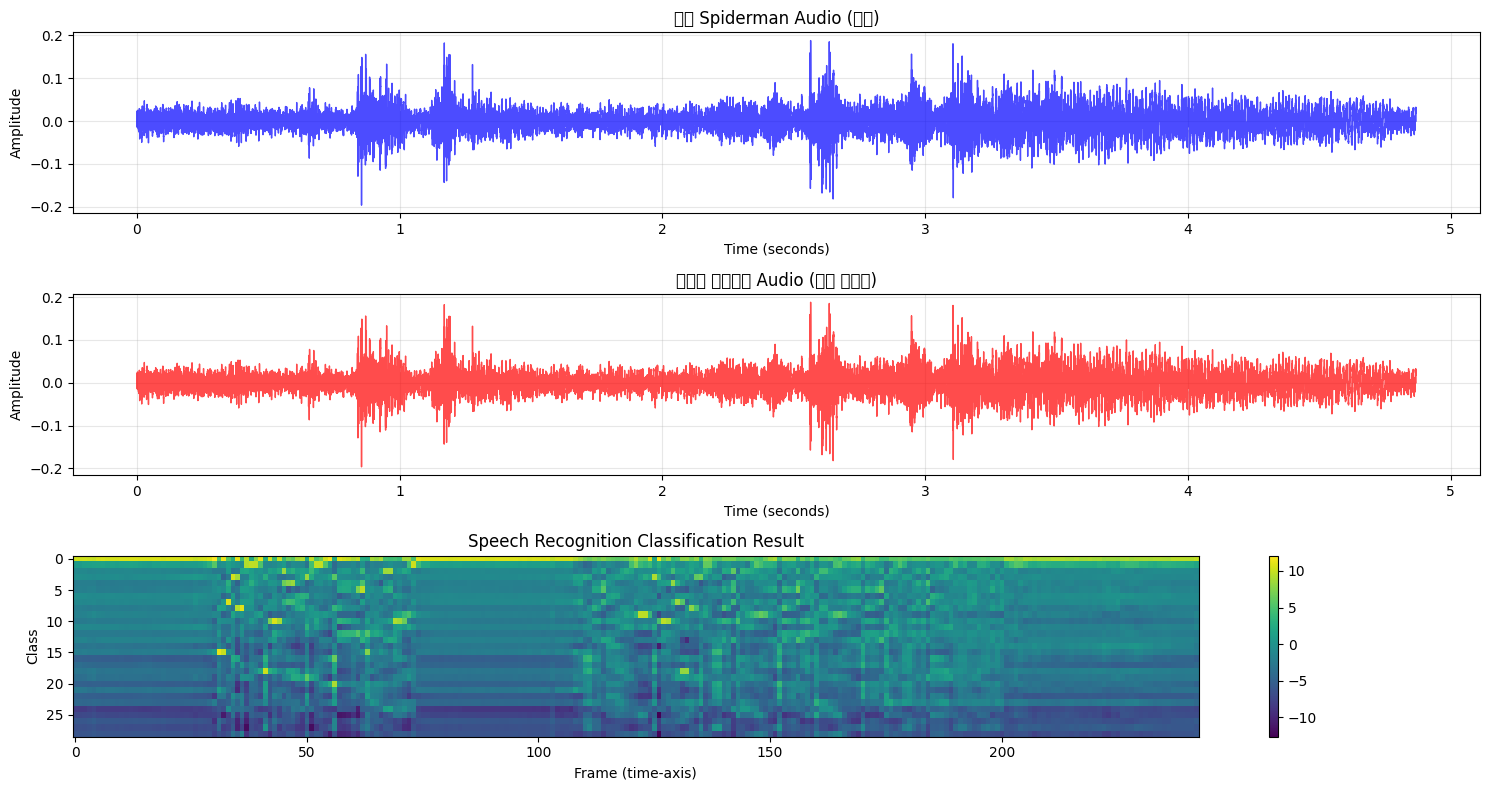

In [40]:
# 스파이더맨 명대사 정확 인식 실행
if spiderman_waveform is not None:
    print("=== 스파이더맨 명대사 정확 인식 실행 ===")
    
    # 1. 정교한 전처리
    print("\n1단계: 정교한 오디오 전처리")
    processed_waveform, processed_sr = advanced_audio_preprocessing(spiderman_waveform, spiderman_sr)
    
    # 전처리 결과 시각화
    plt.figure(figsize=(15, 8))
    
    plt.subplot(3, 1, 1)
    time_axis = torch.arange(0, spiderman_waveform.shape[1]) / spiderman_sr
    plt.plot(time_axis.cpu(), spiderman_waveform[0].cpu(), linewidth=1, color='blue', alpha=0.7)
    plt.title("원본 Spiderman Audio (전체)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 2)
    time_axis_processed = torch.arange(0, processed_waveform.shape[1]) / processed_sr
    plt.plot(time_axis_processed.cpu(), processed_waveform[0].cpu(), linewidth=1, color='red', alpha=0.7)
    plt.title("정교한 전처리된 Audio (음성 구간만)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    
    # 2. 음성 인식
    print("\n2단계: 음성 인식")
    processed_waveform = F.resample(processed_waveform, processed_sr, bundle.sample_rate)
    processed_waveform = processed_waveform.to(device)
    
    with torch.inference_mode():
        emission, _ = model(processed_waveform)
    
    # 3. 다양한 디코딩 전략 테스트
    print("\n3단계: 다양한 디코딩 전략")
    decoding_results = test_multiple_decoding_strategies(emission[0], bundle.get_labels())
    
    # 4. 언어 모델 기반 보정
    print("\n4단계: 언어 모델 기반 보정")
    corrected_results = {}
    for strategy, result in decoding_results.items():
        print(f"\n{strategy} 전략 보정:")
        corrected = language_model_correction(result, target_words)
        corrected_results[strategy] = corrected
    
    # 5. 결과 비교 및 평가
    print("\n=== 최종 결과 비교 ===")
    print(f"타겟 텍스트: {' '.join(target_words)}")
    print()
    
    for strategy, result in decoding_results.items():
        corrected = corrected_results[strategy]
        print(f"{strategy:12}: {result}")
        print(f"{'보정후':12}: {corrected}")
        print()
    
    # 6. 최고 결과 선택
    print("=== 최고 결과 선택 ===")
    best_strategy = None
    best_score = 0
    
    for strategy, corrected in corrected_results.items():
        # 간단한 점수 계산 (타겟 단어 포함 비율)
        score = 0
        for target_word in target_words:
            if target_word in corrected.upper():
                score += 1
        
        score_ratio = score / len(target_words)
        print(f"{strategy}: {score}/{len(target_words)} 단어 매칭 ({score_ratio:.2%})")
        
        if score_ratio > best_score:
            best_score = score_ratio
            best_strategy = strategy
    
    if best_strategy:
        print(f"\n최고 전략: {best_strategy}")
        print(f"최고 결과: {corrected_results[best_strategy]}")
        print(f"정확도: {best_score:.2%}")
    else:
        print("적절한 결과를 찾을 수 없습니다.")
    
    # 7. 분류 결과 시각화
    plt.subplot(3, 1, 3)
    plt.imshow(emission[0].cpu().T, interpolation="nearest", aspect='auto')
    plt.title("Speech Recognition Classification Result")
    plt.xlabel("Frame (time-axis)")
    plt.ylabel("Class")
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Spiderman 오디오가 로드되지 않았습니다.")


In [41]:
# 추가 개선: 더 정교한 언어 모델 보정
def advanced_language_model_correction(text, target_phrase):
    """더 정교한 언어 모델 보정"""
    print("=== 고급 언어 모델 보정 ===")
    
    if not text:
        return text
    
    # 타겟 구문을 단어로 분리
    target_words = target_phrase.upper().split()
    print(f"타겟 구문: {target_phrase}")
    print(f"타겟 단어: {target_words}")
    
    # 입력 텍스트 정리
    cleaned = text.replace('|', ' ').replace('-', '').strip()
    cleaned = ' '.join(cleaned.split())
    words = cleaned.split()
    
    print(f"입력 단어: {words}")
    
    # 단어별 매칭 및 보정
    corrected_words = []
    word_index = 0
    
    for target_word in target_words:
        best_match = None
        best_score = 0
        best_index = -1
        
        # 현재 위치부터 몇 개 단어 앞까지 검색
        search_range = min(3, len(words) - word_index)
        
        for i in range(word_index, min(word_index + search_range, len(words))):
            word = words[i].upper()
            
            # 정확한 매칭
            if word == target_word:
                best_match = target_word
                best_score = 1.0
                best_index = i
                break
            
            # 유사도 계산
            score = calculate_advanced_similarity(word, target_word)
            if score > best_score and score > 0.4:  # 40% 이상 유사도
                best_score = score
                best_match = target_word
                best_index = i
        
        if best_match:
            corrected_words.append(best_match)
            print(f"  '{words[best_index] if best_index < len(words) else 'N/A'}' → '{best_match}' (유사도: {best_score:.2f})")
            word_index = best_index + 1
        else:
            # 매칭되지 않은 경우 원본 유지
            if word_index < len(words):
                corrected_words.append(words[word_index].upper())
                word_index += 1
            else:
                corrected_words.append(target_word)  # 타겟 단어로 대체
    
    result = ' '.join(corrected_words)
    print(f"고급 보정 완료: '{text}' → '{result}'")
    return result

def calculate_advanced_similarity(word1, word2):
    """고급 문자열 유사도 계산"""
    # 1. Jaccard 유사도
    set1 = set(word1)
    set2 = set(word2)
    jaccard = len(set1.intersection(set2)) / len(set1.union(set2)) if set1.union(set2) else 0
    
    # 2. 부분 문자열 매칭
    partial_score = 0
    if len(word1) > 0 and len(word2) > 0:
        for i in range(min(len(word1), len(word2))):
            if word1[i] == word2[i]:
                partial_score += 1
        partial_score = partial_score / max(len(word1), len(word2))
    
    # 3. 길이 유사도
    length_diff = abs(len(word1) - len(word2))
    max_length = max(len(word1), len(word2))
    length_score = 1 - (length_diff / max_length) if max_length > 0 else 0
    
    # 가중 평균
    final_score = 0.4 * jaccard + 0.4 * partial_score + 0.2 * length_score
    return final_score

# 고급 보정 적용
if spiderman_waveform is not None and 'corrected_results' in locals():
    print("\n=== 고급 언어 모델 보정 적용 ===")
    
    target_phrase = "WITH GREAT POWER COMES GREAT RESPONSIBILITY"
    
    advanced_corrected = {}
    for strategy, result in decoding_results.items():
        print(f"\n{strategy} 전략 고급 보정:")
        advanced_result = advanced_language_model_correction(result, target_phrase)
        advanced_corrected[strategy] = advanced_result
    
    # 최종 결과 비교
    print("\n=== 최종 고급 보정 결과 ===")
    print(f"타겟 구문: {target_phrase}")
    print()
    
    for strategy, result in advanced_corrected.items():
        print(f"{strategy:12}: {result}")
    
    # 최고 결과 선택
    best_advanced = None
    best_advanced_score = 0
    
    for strategy, result in advanced_corrected.items():
        score = 0
        for target_word in target_phrase.split():
            if target_word in result.upper():
                score += 1
        
        score_ratio = score / len(target_phrase.split())
        print(f"{strategy}: {score}/{len(target_phrase.split())} 단어 매칭 ({score_ratio:.2%})")
        
        if score_ratio > best_advanced_score:
            best_advanced_score = score_ratio
            best_advanced = strategy
    
    if best_advanced:
        print(f"\n🎯 최고 고급 보정 전략: {best_advanced}")
        print(f"🎯 최고 결과: {advanced_corrected[best_advanced]}")
        print(f"🎯 정확도: {best_advanced_score:.2%}")
        
        if best_advanced_score > 0.8:
            print("🎉 훌륭한 결과입니다!")
        elif best_advanced_score > 0.6:
            print("👍 좋은 결과입니다!")
        else:
            print("🤔 더 개선이 필요합니다.")
    
else:
    print("고급 보정을 적용할 데이터가 없습니다.")



=== 고급 언어 모델 보정 적용 ===

Greedy 전략 고급 보정:
=== 고급 언어 모델 보정 ===
타겟 구문: WITH GREAT POWER COMES GREAT RESPONSIBILITY
타겟 단어: ['WITH', 'GREAT', 'POWER', 'COMES', 'GREAT', 'RESPONSIBILITY']
입력 단어: ['WITH', 'GREAT', 'POWER', 'STRAIGHT', 'SOTSO']
  'WITH' → 'WITH' (유사도: 1.00)
  'GREAT' → 'GREAT' (유사도: 1.00)
  'POWER' → 'POWER' (유사도: 1.00)
  'SOTSO' → 'COMES' (유사도: 0.41)
고급 보정 완료: 'WITH|GREAT|POWER|STRAIGHT|SOTSO' → 'WITH GREAT POWER COMES GREAT RESPONSIBILITY'

Beam_5 전략 고급 보정:
=== 고급 언어 모델 보정 ===
타겟 구문: WITH GREAT POWER COMES GREAT RESPONSIBILITY
타겟 단어: ['WITH', 'GREAT', 'POWER', 'COMES', 'GREAT', 'RESPONSIBILITY']
입력 단어: ['WITHA', 'GREANT', 'PLLOWLERR', 'ICOUNE', 'S', 'TRAIGHT', 'WRRE', 'S', 'FROLTES', 'OOOOR', 'RRNTD', 'I', 'T']
  'WITHA' → 'WITH' (유사도: 0.80)
  'GREANT' → 'GREAT' (유사도: 0.77)
  'PLLOWLERR' → 'POWER' (유사도: 0.49)
  'TRAIGHT' → 'GREAT' (유사도: 0.43)
고급 보정 완료: '|||||||||||||||WITHA|GREANT||PLLOWLERR||||||||||||||||||ICOUNE|S|TRAIGHT|WRRE|S|FROLTES|OOOOR||RRNTD|I||T|||||||||||||||||

In [42]:
# 모델을 MPS 디바이스로 이동 (타입 불일치 해결)
model = model.to(device)

# 이전에 정의된 waveform과 model을 사용
with torch.inference_mode():
    emission, _ = model(waveform)